In [1]:
using JLD
using CairoMakie

In [2]:
set_theme!(
    fontsize=28,
    Legend=(labelsize=28,),
    Axis=(
        xgridvisible=false,
        ygridvisible=false,
    )
)

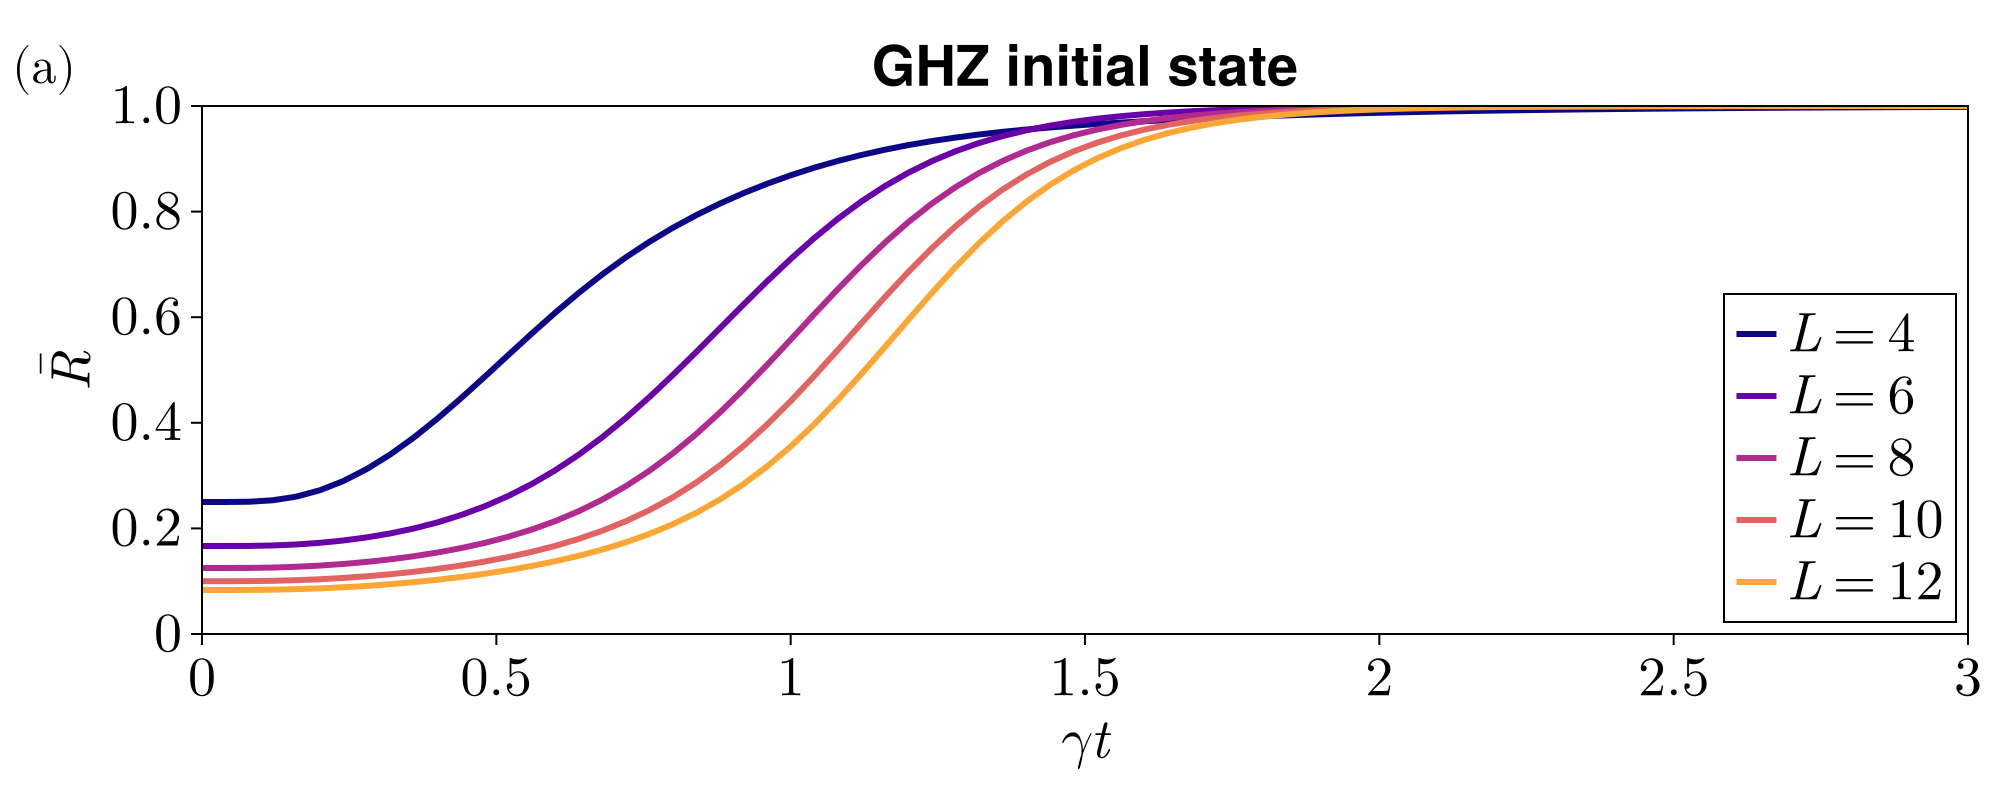

In [3]:
# --- GHZ initial state ---

d1 = load("Ising//GHZ_initial_state//R2_J=1.0_h=0.0_L=4.jld")
d2 = load("Ising//GHZ_initial_state//R2_J=1.0_h=0.0_L=6.jld")
d3 = load("Ising//GHZ_initial_state//R2_J=1.0_h=0.0_L=8.jld")
d4 = load("Ising//GHZ_initial_state//R2_J=1.0_h=0.0_L=10.jld")
d5 = load("Ising//GHZ_initial_state//R2_J=1.0_h=0.0_L=12.jld")

fig = Figure(size=(1000, 400))

ax = Axis(fig[1, 1];
    xticks=(0:0.5:3, [L"0", L"0.5", L"1", L"1.5", L"2", L"2.5", L"3"]),
    yticks=(0:0.2:1.0, [L"0", L"0.2", L"0.4", L"0.6", L"0.8", L"1.0"]),
    xlabel=L"\gamma t",
    ylabel=L"\bar{R}",
    title="GHZ initial state")

xlims!(ax, 0, 3)
ylims!(ax, 0, 1)

cmap = cgrad(:plasma)
color_val = [cmap[(i - 1) / 5] for i in 1:5]

lines!(ax, d1["t"], d1["R2"], label=L"L = 4", linewidth=3, color = color_val[1])
lines!(ax, d2["t"], d2["R2"], label=L"L = 6", linewidth=3, color = color_val[2])
lines!(ax, d3["t"], d3["R2"], label=L"L = 8", linewidth=3, color = color_val[3])
lines!(ax, d4["t"], d4["R2"], label=L"L = 10", linewidth=3, color = color_val[4])
lines!(ax, d5["t"], d5["R2"], label=L"L = 12", linewidth=3, color = color_val[5])

Label(fig[1, 1, TopLeft()], L"\mathrm{(a)}";
    fontsize=25,
    halign=:left,
    padding  = (-10, 0, 0, 0))

axislegend(ax; position=:rb)

fig

slope: 0.43034265657834525


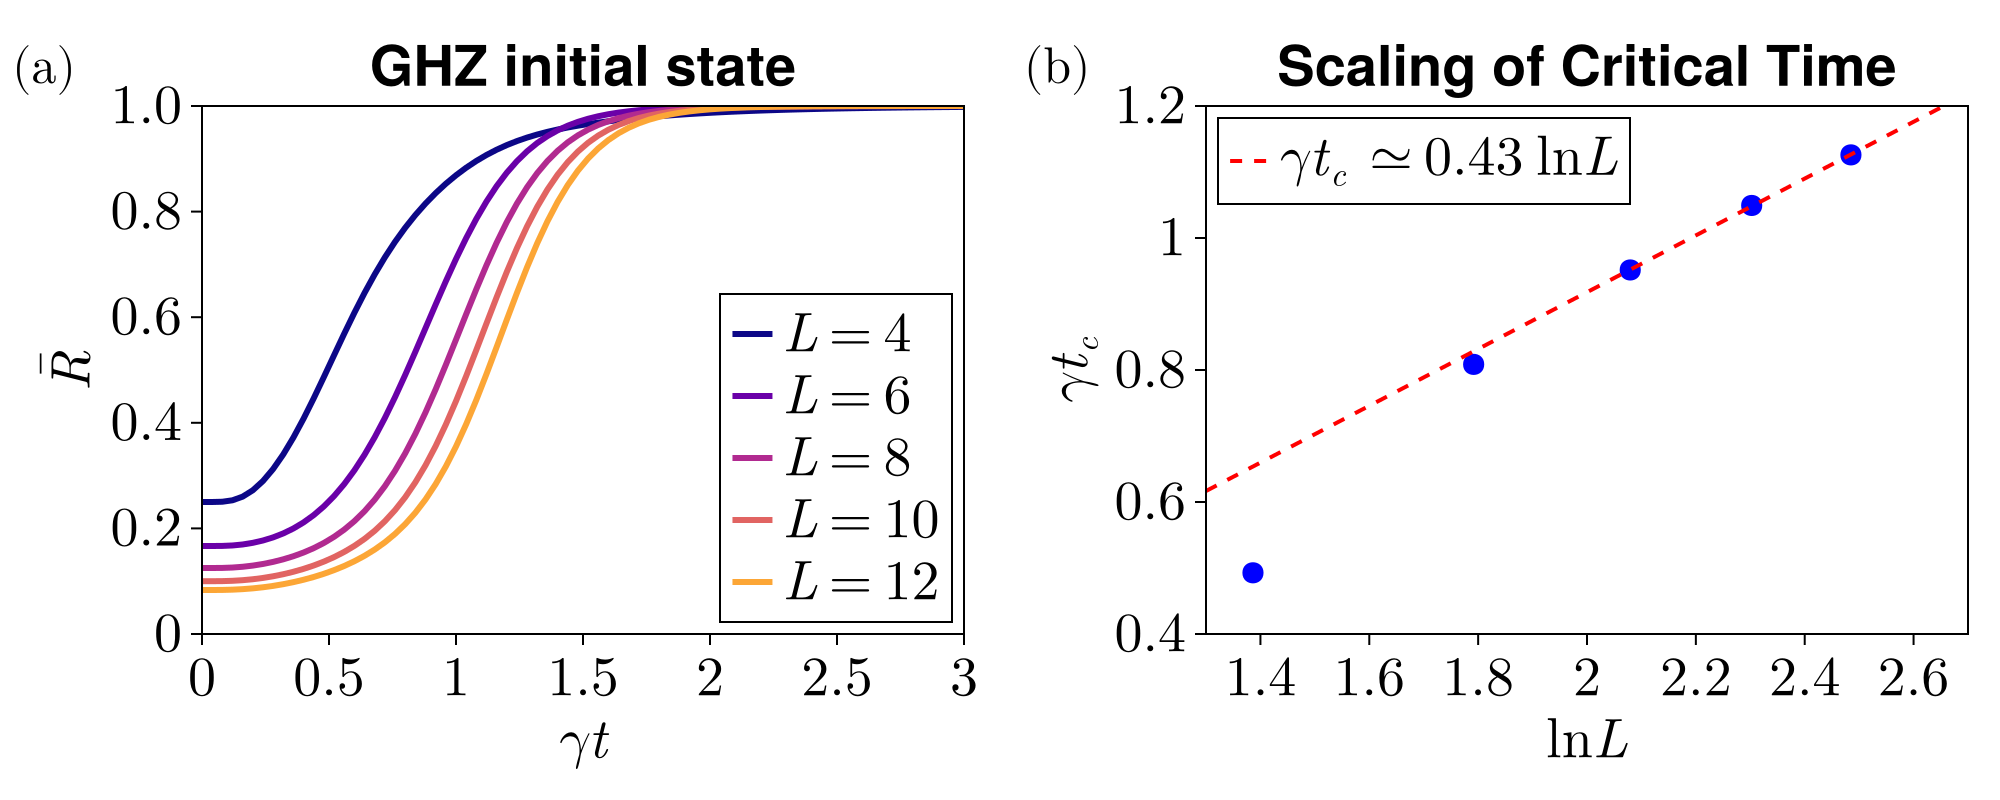

In [4]:
function find_tc(t_vals, r2_vals, threshold=0.5)
    for i in 1:(length(r2_vals)-1)
        y1 = r2_vals[i]
        y2 = r2_vals[i+1]
        
        if (y1 <= threshold && y2 >= threshold) || (y1 >= threshold && y2 <= threshold)
            t1 = t_vals[i]
            t2 = t_vals[i+1]
            slope = (y2 - y1) / (t2 - t1)
            return t1 + (threshold - y1) / slope
        end
    end
    return NaN
end

data_points = []
tc = find_tc(d1["t"], d1["R2"], 0.5)
push!(data_points, (4, tc))
tc = find_tc(d2["t"], d2["R2"], 0.5)
push!(data_points, (6, tc))
tc = find_tc(d3["t"], d3["R2"], 0.5)
push!(data_points, (8, tc))
tc = find_tc(d4["t"], d4["R2"], 0.5)
push!(data_points, (10, tc))
tc = find_tc(d5["t"], d5["R2"], 0.5)
push!(data_points, (12, tc))

Ls_plot = [p[1] for p in data_points]
tcs_plot = [p[2] for p in data_points]
log_Ls = log.(Ls_plot)

ax = Axis(fig[1, 2],
    xticks=(1.4:0.2:2.6, [L"1.4", L"1.6", L"1.8", L"2", L"2.2", L"2.4", L"2.6"]),
    yticks=(0.4:0.2:1.2, [L"0.4", L"0.6", L"0.8", L"1", L"1.2"]),
    title = "Scaling of Critical Time",
    xlabel = L"\ln L",
    ylabel = L"\gamma t_c"
)

xlims!(ax, 1.3, 2.7)
ylims!(ax, 0.4, 1.2)

scatter!(ax, log_Ls, tcs_plot,
    color = :blue, markersize = 15
)

X = hcat(ones(length(log_Ls[3:end])), log_Ls[3:end])
coeffs = X \ tcs_plot[3:end]
a_intercept, b_slope = coeffs
xs = 1.0:0.1:3.0
ys = b_slope * xs .+ a_intercept

println("slope: ", b_slope)

lines!(ax, xs, ys, 
    label = L"\gamma t_c \: \simeq 0.43 \: \ln L", 
    color = :red, linestyle = :dash, linewidth = 2
)

axislegend(ax, position = :lt)

Label(fig[1, 2, TopLeft()], L"\mathrm{(b)}";
    fontsize=25,
    halign=:left,
    padding  = (-10, 0, 0, 0))

colgap!(fig.layout, 1, Relative(0.05))

fig

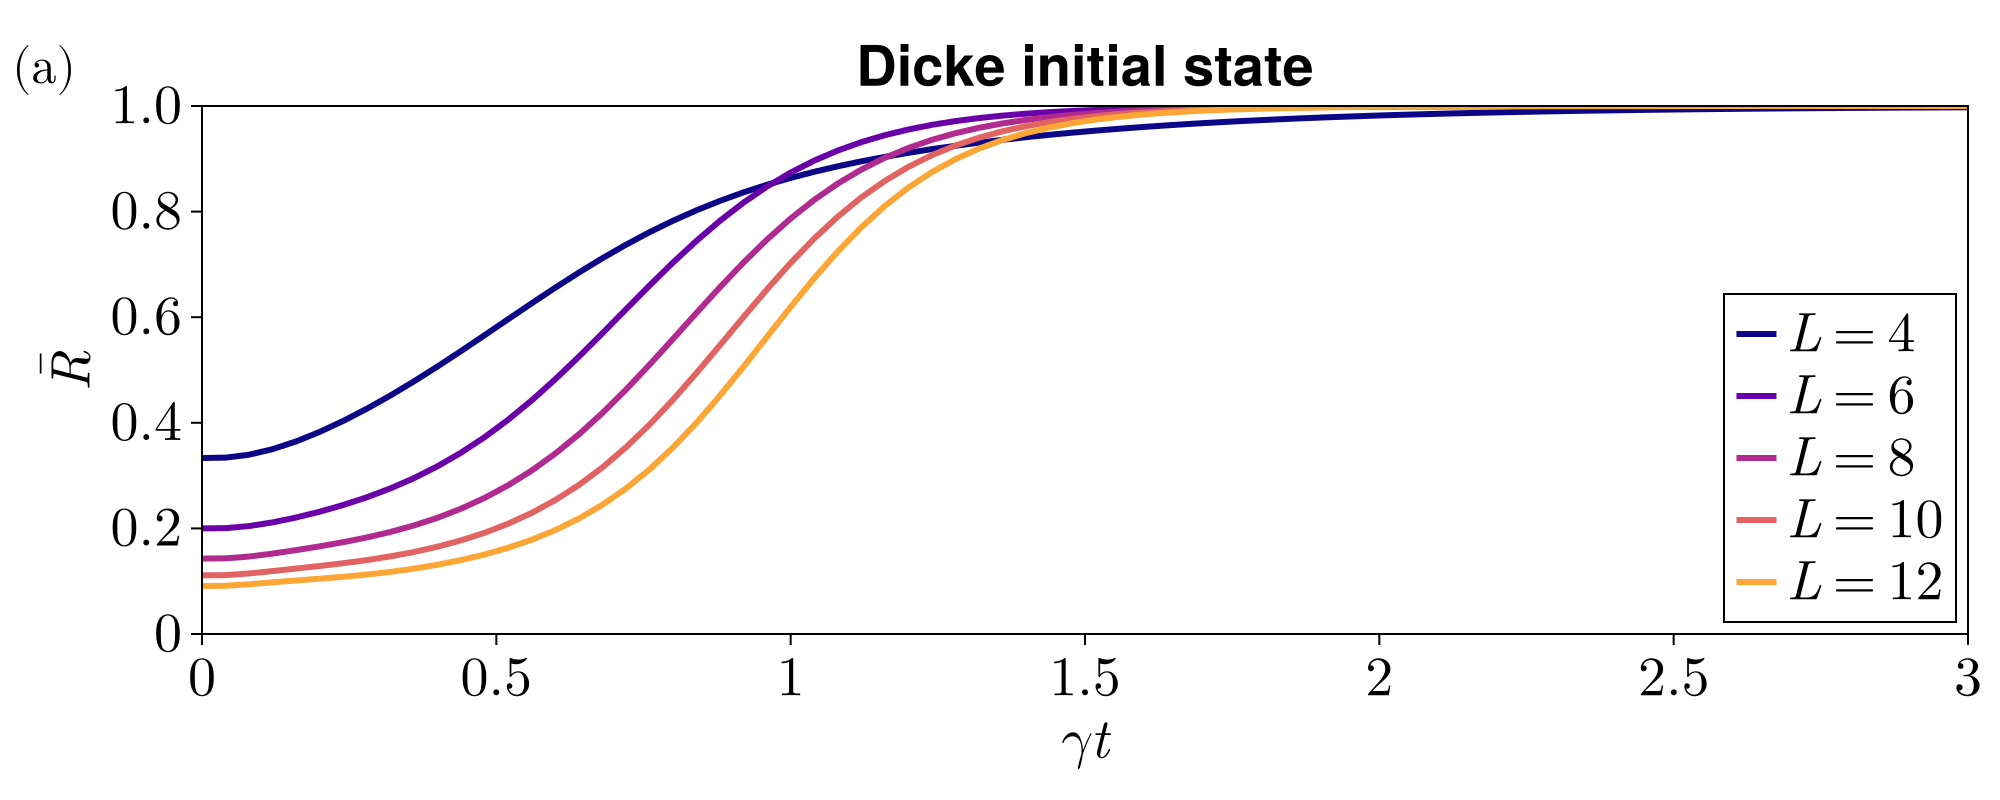

In [5]:
# --- Dicke initial state ---

d1 = load("Ising//Dicke_initial_state//R2_J=1.0_h=0.0_L=4.jld")
d2 = load("Ising//Dicke_initial_state//R2_J=1.0_h=0.0_L=6.jld")
d3 = load("Ising//Dicke_initial_state//R2_J=1.0_h=0.0_L=8.jld")
d4 = load("Ising//Dicke_initial_state//R2_J=1.0_h=0.0_L=10.jld")
d5 = load("Ising//Dicke_initial_state//R2_J=1.0_h=0.0_L=12.jld")

fig = Figure(size=(1000, 400))

ax = Axis(fig[1, 1];
    xticks=(0:0.5:3, [L"0", L"0.5", L"1", L"1.5", L"2", L"2.5", L"3"]),
    yticks=(0:0.2:1.0, [L"0", L"0.2", L"0.4", L"0.6", L"0.8", L"1.0"]),
    xlabel=L"\gamma t",
    ylabel=L"\bar{R}",
    title="Dicke initial state")

xlims!(ax, 0, 3)
ylims!(ax, 0, 1)

cmap = cgrad(:plasma)
color_val = [cmap[(i - 1) / 5] for i in 1:5]

lines!(ax, d1["t"], d1["R2"], label=L"L = 4", linewidth=3, color = color_val[1])
lines!(ax, d2["t"], d2["R2"], label=L"L = 6", linewidth=3, color = color_val[2])
lines!(ax, d3["t"], d3["R2"], label=L"L = 8", linewidth=3, color = color_val[3])
lines!(ax, d4["t"], d4["R2"], label=L"L = 10", linewidth=3, color = color_val[4])
lines!(ax, d5["t"], d5["R2"], label=L"L = 12", linewidth=3, color = color_val[5])

Label(fig[1, 1, TopLeft()], L"\mathrm{(a)}";
    fontsize=25,
    halign=:left,
    padding  = (-10, 0, 0, 0))

axislegend(ax; position=:rb)

fig

slope: 0.40372534754854544


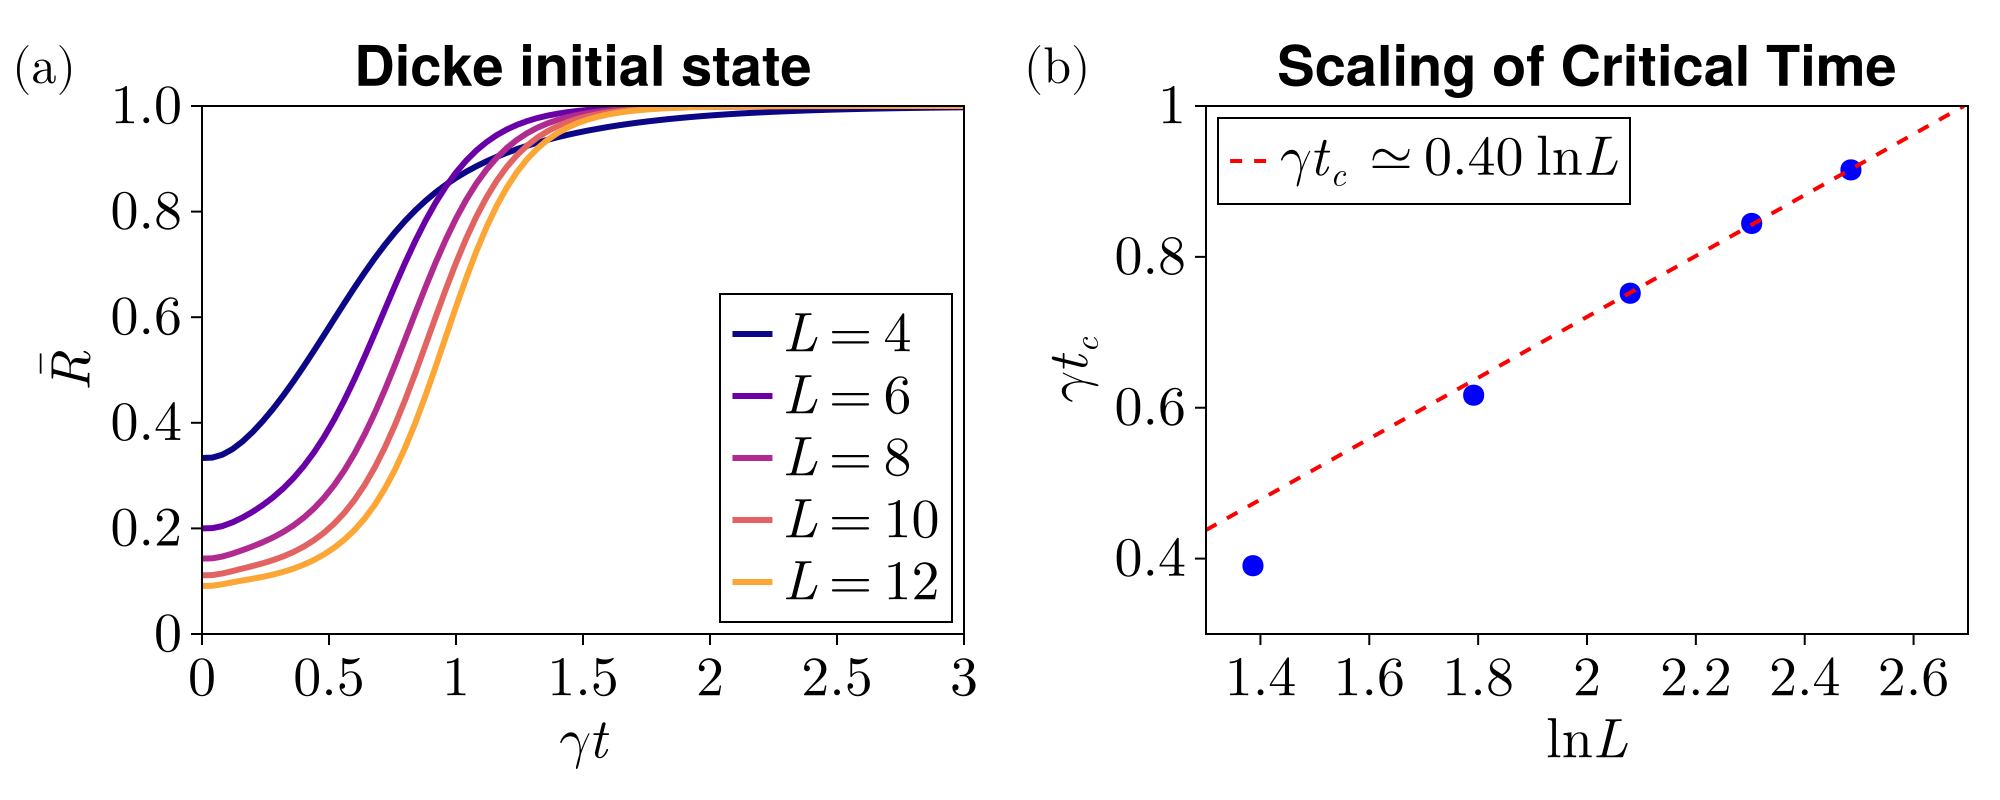

In [6]:
data_points = []
tc = find_tc(d1["t"], d1["R2"], 0.5)
push!(data_points, (4, tc))
tc = find_tc(d2["t"], d2["R2"], 0.5)
push!(data_points, (6, tc))
tc = find_tc(d3["t"], d3["R2"], 0.5)
push!(data_points, (8, tc))
tc = find_tc(d4["t"], d4["R2"], 0.5)
push!(data_points, (10, tc))
tc = find_tc(d5["t"], d5["R2"], 0.5)
push!(data_points, (12, tc))

Ls_plot = [p[1] for p in data_points]
tcs_plot = [p[2] for p in data_points]
log_Ls = log.(Ls_plot)

ax = Axis(fig[1, 2],
    xticks=(1.4:0.2:2.6, [L"1.4", L"1.6", L"1.8", L"2", L"2.2", L"2.4", L"2.6"]),
    yticks=(0.4:0.2:1.2, [L"0.4", L"0.6", L"0.8", L"1", L"1.2"]),
    title = "Scaling of Critical Time",
    xlabel = L"\ln L",
    ylabel = L"\gamma t_c"
)

xlims!(ax, 1.3, 2.7)
ylims!(ax, 0.3, 1.0)

scatter!(ax, log_Ls, tcs_plot,
    color = :blue, markersize = 15
)

X = hcat(ones(length(log_Ls[3:end])), log_Ls[3:end])
coeffs = X \ tcs_plot[3:end]
a_intercept, b_slope = coeffs
xs = 1.0:0.1:3.0
ys = b_slope * xs .+ a_intercept

println("slope: ", b_slope)

lines!(ax, xs, ys, 
    label = L"\gamma t_c \: \simeq 0.40 \: \ln L", 
    color = :red, linestyle = :dash, linewidth = 2
)

axislegend(ax, position = :lt)

Label(fig[1, 2, TopLeft()], L"\mathrm{(b)}";
    fontsize=25,
    halign=:left,
    padding  = (-10, 0, 0, 0))

colgap!(fig.layout, 1, Relative(0.05))

fig

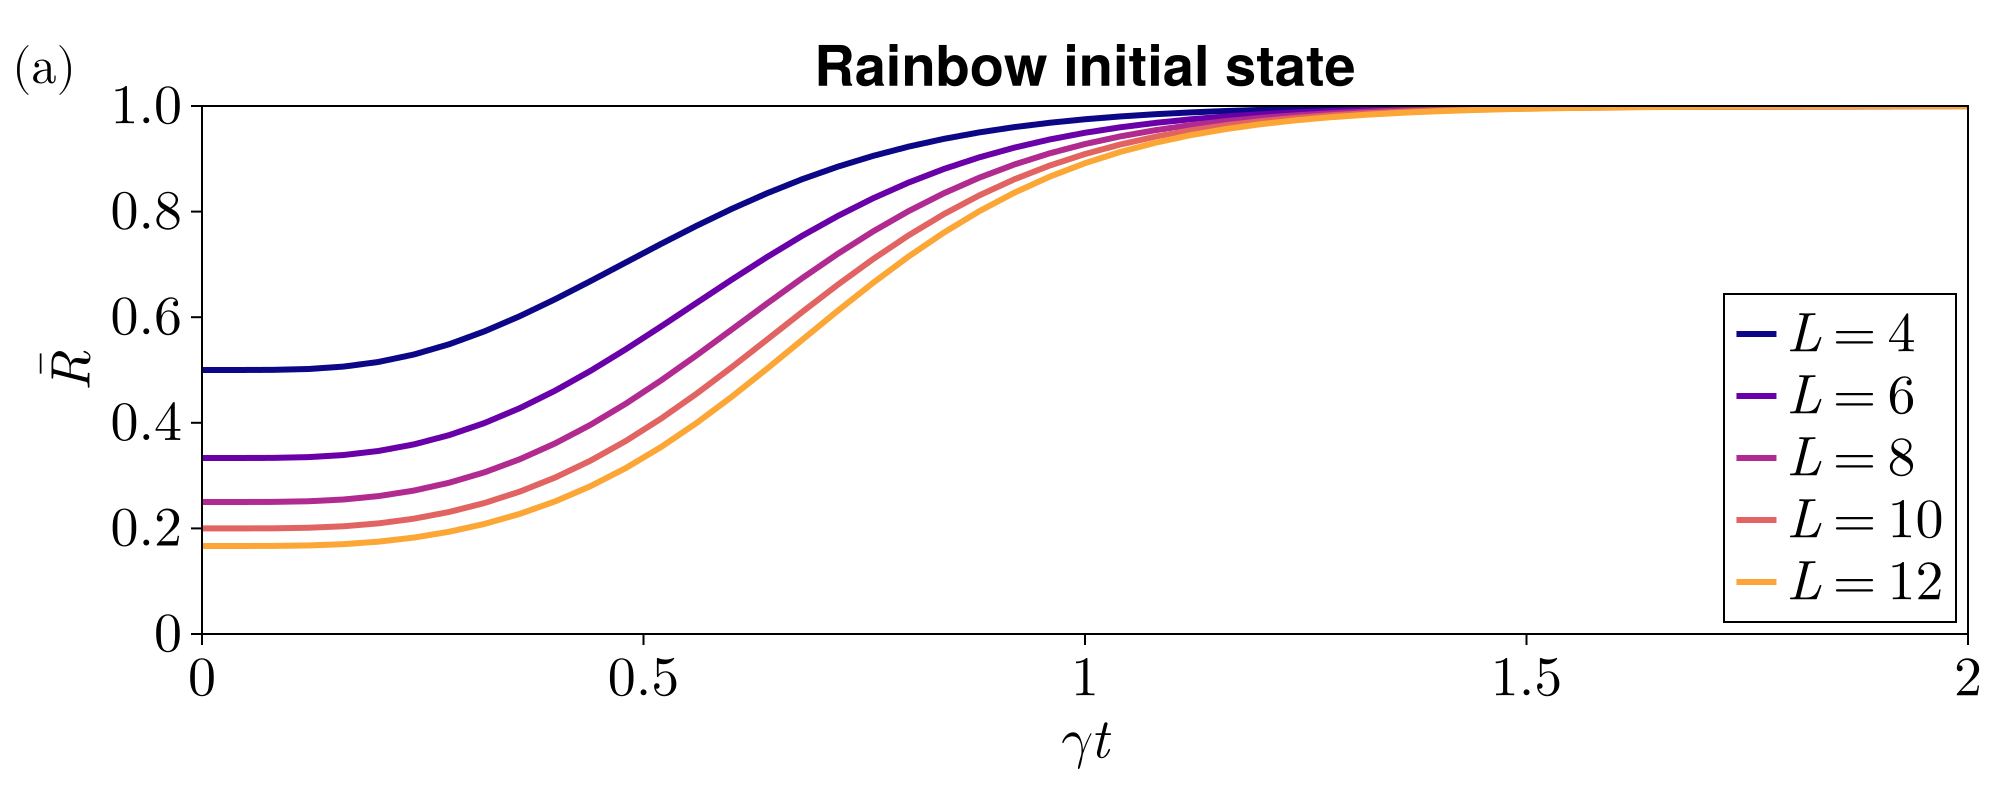

In [7]:
# --- Rainbow initial state ---

d1 = load("Ising//Rainbow_initial_state//R2_J=1.0_h=0.0_L=4.jld")
d2 = load("Ising//Rainbow_initial_state//R2_J=1.0_h=0.0_L=6.jld")
d3 = load("Ising//Rainbow_initial_state//R2_J=1.0_h=0.0_L=8.jld")
d4 = load("Ising//Rainbow_initial_state//R2_J=1.0_h=0.0_L=10.jld")
d5 = load("Ising//Rainbow_initial_state//R2_J=1.0_h=0.0_L=12.jld")

fig = Figure(size=(1000, 400))

ax = Axis(fig[1, 1];
    xticks=(0:0.5:3, [L"0", L"0.5", L"1", L"1.5", L"2", L"2.5", L"3"]),
    yticks=(0:0.2:1.0, [L"0", L"0.2", L"0.4", L"0.6", L"0.8", L"1.0"]),
    xlabel=L"\gamma t",
    ylabel=L"\bar{R}",
    title="Rainbow initial state")

xlims!(ax, 0, 2)
ylims!(ax, 0, 1)

cmap = cgrad(:plasma)
color_val = [cmap[(i - 1) / 5] for i in 1:5]

lines!(ax, d1["t"], d1["R2"], label=L"L = 4", linewidth=3, color = color_val[1])
lines!(ax, d2["t"], d2["R2"], label=L"L = 6", linewidth=3, color = color_val[2])
lines!(ax, d3["t"], d3["R2"], label=L"L = 8", linewidth=3, color = color_val[3])
lines!(ax, d4["t"], d4["R2"], label=L"L = 10", linewidth=3, color = color_val[4])
lines!(ax, d5["t"], d5["R2"], label=L"L = 12", linewidth=3, color = color_val[5])

Label(fig[1, 1, TopLeft()], L"\mathrm{(a)}";
    fontsize=25,
    halign=:left,
    padding  = (-10, 0, 0, 0))

axislegend(ax; position=:rb)

fig

slope: 0.2507996244862059


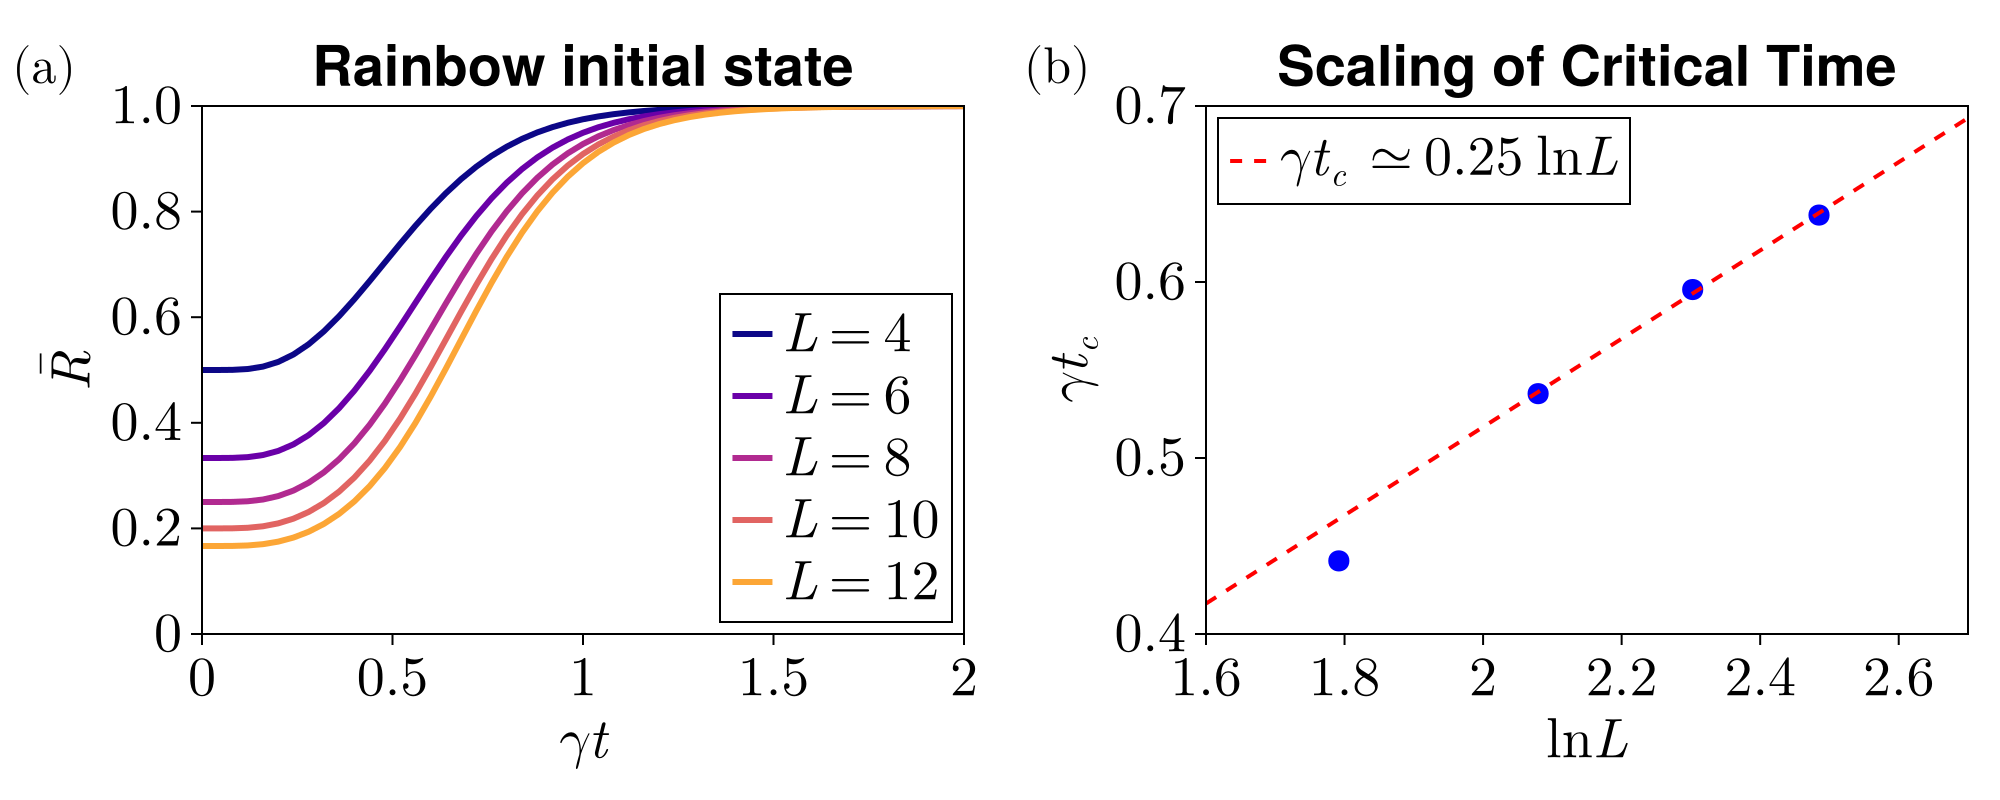

In [8]:
data_points = []
tc = find_tc(d1["t"], d1["R2"], 0.5)
push!(data_points, (4, tc))
tc = find_tc(d2["t"], d2["R2"], 0.5)
push!(data_points, (6, tc))
tc = find_tc(d3["t"], d3["R2"], 0.5)
push!(data_points, (8, tc))
tc = find_tc(d4["t"], d4["R2"], 0.5)
push!(data_points, (10, tc))
tc = find_tc(d5["t"], d5["R2"], 0.5)
push!(data_points, (12, tc))

Ls_plot = [p[1] for p in data_points]
tcs_plot = [p[2] for p in data_points]
log_Ls = log.(Ls_plot)

ax = Axis(fig[1, 2],
    xticks=(1.4:0.2:2.6, [L"1.4", L"1.6", L"1.8", L"2", L"2.2", L"2.4", L"2.6"]),
    yticks=(0.4:0.1:0.7, [L"0.4", L"0.5", L"0.6", L"0.7"]),
    title = "Scaling of Critical Time",
    xlabel = L"\ln L",
    ylabel = L"\gamma t_c"
)

xlims!(ax, 1.6, 2.7)
ylims!(ax, 0.4, 0.7)

scatter!(ax, log_Ls, tcs_plot,
    color = :blue, markersize = 15
)

X = hcat(ones(length(log_Ls[3:end])), log_Ls[3:end])
coeffs = X \ tcs_plot[3:end]
a_intercept, b_slope = coeffs
xs = 1.0:0.1:3.0
ys = b_slope * xs .+ a_intercept

println("slope: ", b_slope)

lines!(ax, xs, ys, 
    label = L"\gamma t_c \: \simeq 0.25 \: \ln L", 
    color = :red, linestyle = :dash, linewidth = 2
)

axislegend(ax, position = :lt)

Label(fig[1, 2, TopLeft()], L"\mathrm{(b)}";
    fontsize=25,
    halign=:left,
    padding  = (-10, 0, 0, 0))

colgap!(fig.layout, 1, Relative(0.05))

fig